# Poisson SLDS with switching rotational dynamics

This example uses a two-dimensional continuous latent trajectory with two discrete
dynamical states: clockwise and counter-clockwise rotation. A shared population of
Poisson neurons reads out the same latent space in both states, so the discrete state
is identified by how the latent trajectory moves rather than by where it is.


In [1]:
%matplotlib inline

import _plotting as plot
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from xxm.core.align import align_procrustes as align_latent
from xxm.core.align import match_states_to_true as match_states
from xxm.slds import PoissonSLDS

In [2]:
NUM_NEURONS = 12
NUM_STEPS = 1_500


def make_rotation(angle: float, radius: float) -> jax.Array:
    """Return a damped 2D rotation matrix."""
    return radius * jnp.array(
        [
            [jnp.cos(angle), -jnp.sin(angle)],
            [jnp.sin(angle), jnp.cos(angle)],
        ]
    )


def make_emission_coefficients(
    num_neurons: int,
    scale: float,
) -> jax.Array:
    """Arrange Poisson readout directions uniformly around the latent plane."""
    preferred_angles = jnp.linspace(
        0.0,
        2.0 * jnp.pi,
        num_neurons,
        endpoint=False,
    )

    return scale * jnp.stack(
        [
            jnp.cos(preferred_angles),
            jnp.sin(preferred_angles),
        ],
        axis=1,
    )


def make_true_model(
    *,
    num_neurons: int,
    angle: float = 0.18,
    radius: float = 0.995,
    self_transition_prob: float = 0.98,
    initial_radius: float = 1.5,
    initial_variance: float = 0.05,
    dynamics_variance: float = 0.01,
    emission_scale: float = 0.45,
    base_rate: float = 4.0,
) -> PoissonSLDS:
    """Build a two-state Poisson SLDS with opposing rotational dynamics."""
    dynamics_coefficients = jnp.stack(
        [
            make_rotation(-angle, radius),
            make_rotation(angle, radius),
        ]
    )

    num_states = dynamics_coefficients.shape[0]
    latent_dim = dynamics_coefficients.shape[-1]
    switch_prob = 1.0 - self_transition_prob

    emission_coefficients = make_emission_coefficients(
        num_neurons=num_neurons,
        scale=emission_scale,
    )

    return PoissonSLDS.from_params(
        initial_probs=jnp.full(num_states, 1.0 / num_states),
        transition_probs=jnp.array(
            [
                [self_transition_prob, switch_prob],
                [switch_prob, self_transition_prob],
            ]
        ),
        latent_initial_means=jnp.tile(
            jnp.array([initial_radius, 0.0]),
            (num_states, 1),
        ),
        latent_initial_covariances=jnp.tile(
            initial_variance * jnp.eye(latent_dim),
            (num_states, 1, 1),
        ),
        dynamics_coefficients=dynamics_coefficients,
        dynamics_bias=jnp.zeros((num_states, latent_dim)),
        dynamics_covariances=jnp.tile(
            dynamics_variance * jnp.eye(latent_dim),
            (num_states, 1, 1),
        ),
        emission_coefficients=emission_coefficients,
        emission_bias=jnp.full(
            num_neurons,
            jnp.log(base_rate),
        ),
    )


true_model = make_true_model(
    num_neurons=NUM_NEURONS,
)

true_states, true_latents, observations = true_model.sample(
    key=jax.random.key(0),
    num_steps=NUM_STEPS,
)

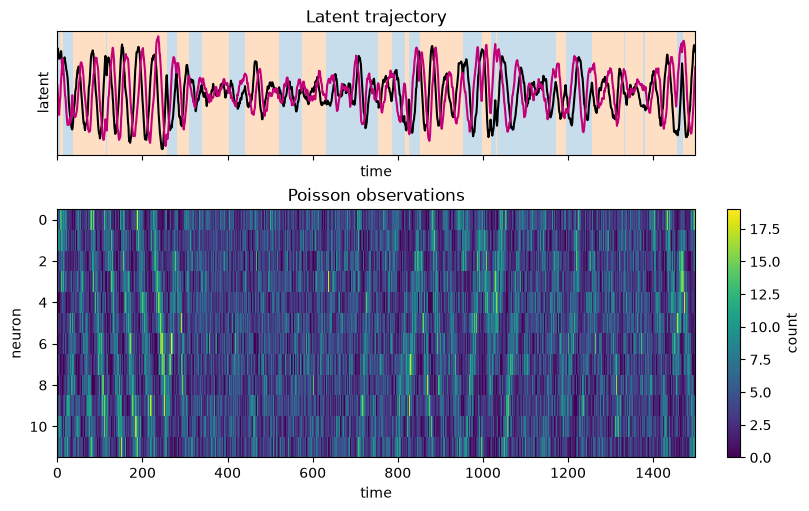

In [3]:
def plot_data(
    states,
    latents,
    observations,
) -> None:
    _, axs = plt.subplots(
        nrows=2,
        sharex='all',
        figsize=(8, 5),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [1, 2]},
    )

    plot.plot_seq_1d(
        axs[0],
        states,
        latents,
        desc='latent',
    )
    axs[0].set(title='Latent trajectory')

    plot.plot_traces_image(
        axs[1],
        observations,
        ylabel='neuron',
        desc='count',
    )
    axs[1].set(title='Poisson observations')


plot_data(
    true_states,
    true_latents,
    observations,
)

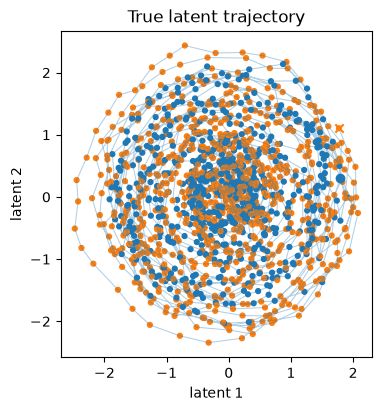

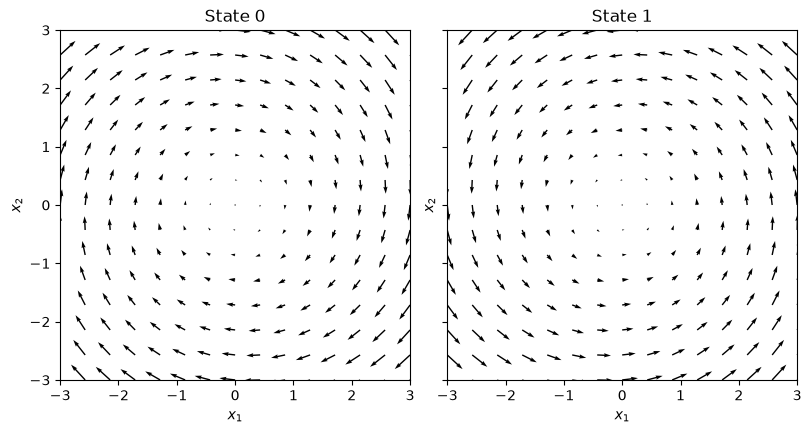

In [4]:
_, ax = plt.subplots(
    figsize=(4, 4),
    constrained_layout=True,
)

plot.plot_seq_2d(
    ax,
    true_states,
    true_latents,
    desc='latent',
)
ax.set(title='True latent trajectory')

plot.plot_dyn_conditional_linear(true_model.dynamics)

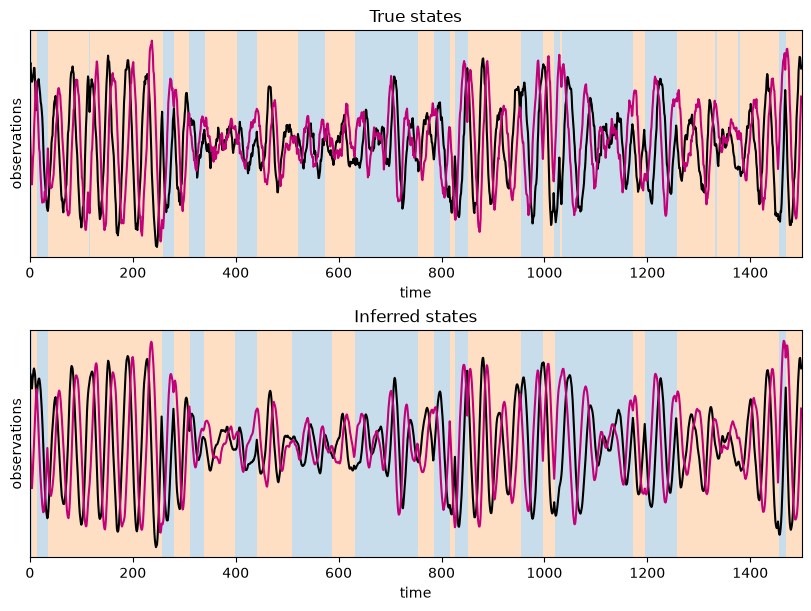

In [5]:
oracle_posterior, _ = true_model.infer(
    observations,
    num_iters=20,
)

oracle_states = true_model.most_likely_states(oracle_posterior)
oracle_latents = true_model.latent_mean(oracle_posterior)


plot.plot_seq_1d_comparison(
    true_states,
    true_latents,
    oracle_states,
    oracle_latents,
)

AR-HMM:   0%|          | 0/100 [00:00<?, ?it/s]

Laplace EM:   0%|          | 0/50 [00:00<?, ?it/s]

[Text(0.5, 1.0, 'Laplace EM')]

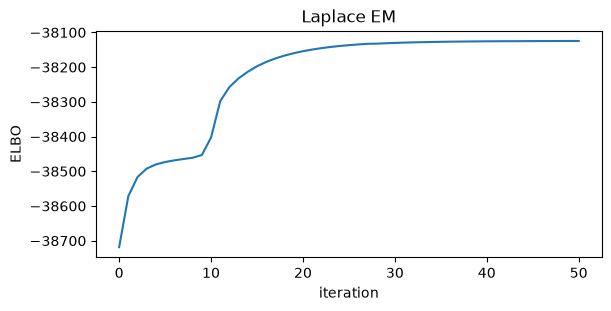

In [6]:
initial_model = PoissonSLDS.from_arhmm(
    key=jax.random.key(1),
    observations=observations,
    num_states=true_model.num_states,
    latent_dim=true_model.latent_dim,
    num_arhmm_iters=100,
)

fit = initial_model.fit(
    observations,
    num_iters=50,
    num_inference_iters=20,
)

learned_model = fit.model


fig, ax = plt.subplots(
    figsize=(6, 3),
    constrained_layout=True,
)

plot.plot_fit_progress(
    fit.objective_trace,
    name='ELBO',
    ax=ax,
)
ax.set(title='Laplace EM')

In [7]:
def align_model(
    model: PoissonSLDS,
    observations: jax.Array,
    true_states: jax.Array,
    true_latents: jax.Array,
    *,
    num_inference_iters: int,
) -> PoissonSLDS:
    posterior, _ = model.infer(
        observations,
        num_iters=num_inference_iters,
    )

    permutation = match_states(
        posterior.discrete.state_probs,
        true_states,
    )

    model = model.permute(permutation)
    posterior = posterior.permute(permutation)

    inferred_latents = model.latent_mean(posterior)
    alignment = align_latent(
        inferred_latents,
        true_latents,
    )

    return model.align(alignment)


matched_model = align_model(
    learned_model,
    observations,
    true_states,
    true_latents,
    num_inference_iters=20,
)

posterior, _ = matched_model.infer(
    observations,
    num_iters=20,
)

inferred_states = matched_model.most_likely_states(posterior)
inferred_latents = matched_model.latent_mean(posterior)
reconstruction = matched_model.observation_mean(posterior)

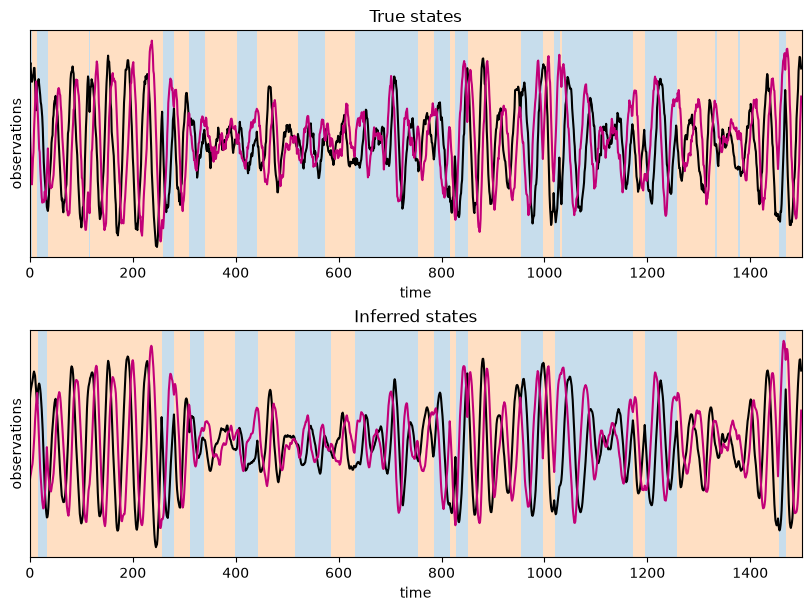

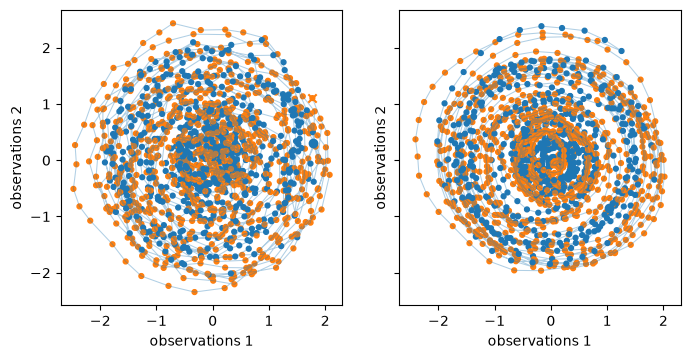

In [8]:
plot.plot_seq_1d_comparison(
    true_states,
    true_latents,
    inferred_states,
    inferred_latents,
)

plot.plot_seq_2d_comparison(
    true_states,
    true_latents,
    inferred_states,
    inferred_latents,
)

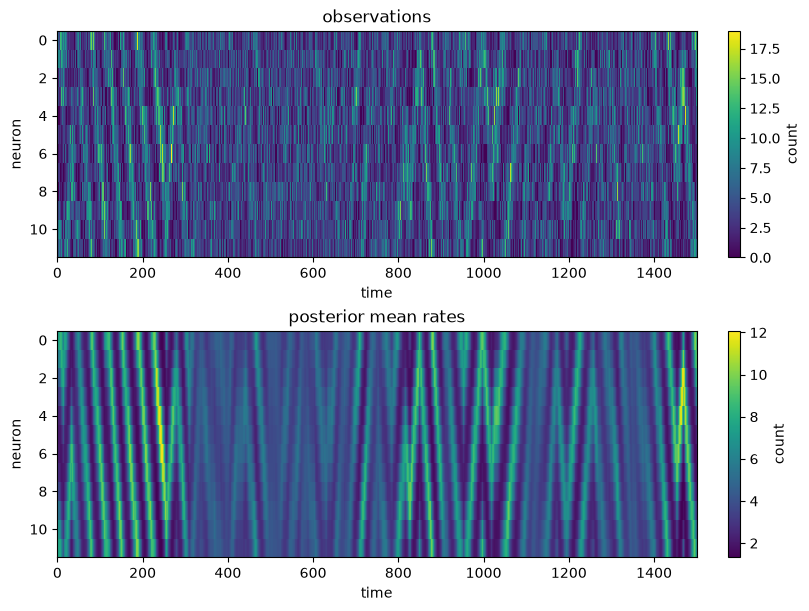

In [9]:
plot.plot_traces_image_comparison(
    observations,
    reconstruction,
    ylabel='neuron',
    name0='observations',
    name1='posterior mean rates',
    desc='count',
)

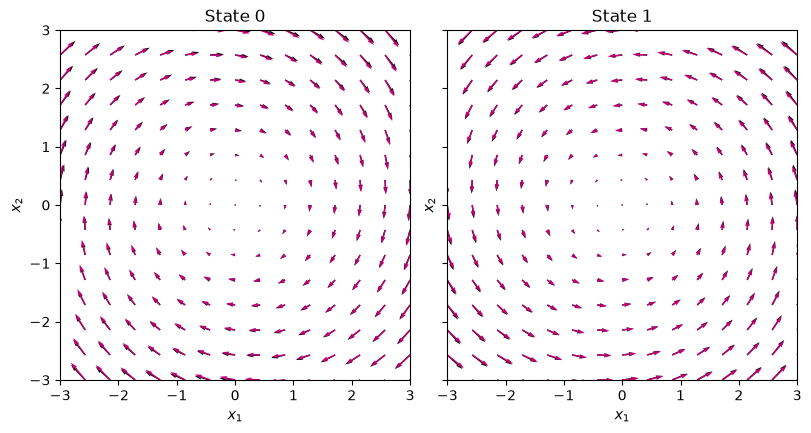

In [10]:
plot.plot_dyn_conditional_linear_comparison(
    true_model.dynamics,
    matched_model.dynamics,
)